In [367]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [368]:
df = pd.read_csv('mengantuk.csv')

In [369]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Tingkat Theta        1000 non-null   float64
 1   Indeks Kedipan Mata  1000 non-null   float64
 2   Status Kantuk        1000 non-null   object 
dtypes: float64(2), object(1)
memory usage: 23.6+ KB


In [370]:
df['Status Kantuk'] = df['Status Kantuk'].map({'Tidak Mengantuk':0, 'Mengantuk':1})

In [371]:
df.head(10)

,Tingkat Theta,Indeks Kedipan Mata,Status Kantuk
0,4.16,21.75,0
1,13.00,15.87,1
2,7.45,14.09,1
3,10.69,15.83,1
4,9.28,23.36,1
5,11.59,17.98,1
6,10.81,16.02,1
7,2.88,25.43,0
8,7.70,14.21,1
9,2.42,27.60,0


In [372]:
print(df.isnull().sum())
print(df.duplicated().sum())

Tingkat Theta          0
Indeks Kedipan Mata    0
Status Kantuk          0
dtype: int64
0


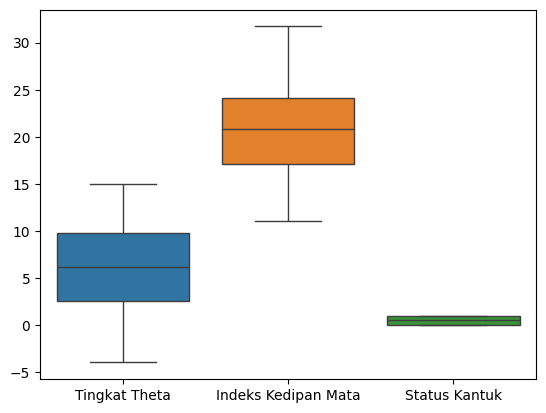

In [373]:
sns.boxplot(df)
plt.show()

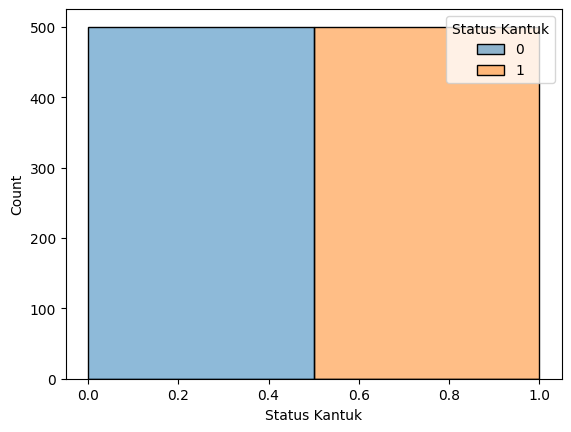

In [374]:
sns.histplot(data=df, x=df['Status Kantuk'], hue=df['Status Kantuk'],  bins=2)
plt.show()


In [375]:
a = df[df['Status Kantuk'] == 0]
a.head()

,Tingkat Theta,Indeks Kedipan Mata,Status Kantuk
0,4.16,21.75,0
7,2.88,25.43,0
9,2.42,27.60,0
13,-1.56,24.39,0
15,2.73,25.04,0


In [376]:
b = df[df['Status Kantuk'] == 1]
b.head()

,Tingkat Theta,Indeks Kedipan Mata,Status Kantuk
1,13.00,15.87,1
2,7.45,14.09,1
3,10.69,15.83,1
4,9.28,23.36,1
5,11.59,17.98,1


In [377]:
X = df.drop('Status Kantuk', axis=1).values
y = df['Status Kantuk'].values

In [378]:
idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]

np.random.shuffle(idx_0)
np.random.shuffle(idx_1)

train_0 = int(0.8 * len(idx_0))
train_1 = int(0.8 * len(idx_1))

train_idx = np.concatenate((idx_0[:train_0], idx_1[:train_1]))
test_idx = np.concatenate((idx_0[train_0:], idx_1[train_1:]))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

In [379]:
def scaling(X):
    n_features = len(X[0])
    mean = []
    std = []

    for j in range(n_features):
        column = [row[j] for row in X]
        m = sum(column) / len(column)
        s = (sum((x - m)**2 for x in column) / len(column))**0.5
        mean.append(m)
        std.append(s)
    return mean, std

def apply(X, mean, std):
    X_scaled = []
    for row in X:
        new_row = []
        for j in range(len(row)):
            scaled = (row[j] - mean[j]) / (std[j] + 1e-9)            
            new_row.append(scaled)
        X_scaled.append(new_row)
    return X_scaled
    
mean, std = scaling(X_train)

X_train_scaled = apply(X_train, mean, std)
X_test_scaled = apply(X_test, mean, std)

In [380]:
def train_svm(X, y, learning_rate=0.000001, lambda_param=0.001, n_iters=20000):
    n_sampled, n_features = len(X), len(X[0])
    w = [0.0] * n_features
    b = 0.0
    y_svm = [1 if val == 1 else -1 for val in y]

    for _ in range(n_iters):
        for idx, x_i in enumerate(X):
            y_i = y_svm[idx]
            approx = sum(x_i[j] * w[j] for j in range(n_features)) + b
            condition = y_i * approx >= 1

            if condition:
                for j in range(n_features):
                    w[j] -= learning_rate * (2 * lambda_param * w[j])
            else:
                for j in range(n_features):
                    w[j] -= learning_rate * (2 * lambda_param * w[j] - x_i[j] * y_i)
                b -= learning_rate * y_i
    return w, b

weights, bias = train_svm(X_train_scaled, y_train)

In [381]:
def predict(X, w, b):
    predictions = []
    for x_i in X:
        approx = sum(x_i[j] * w[j] for j in range(len(w))) + b
        predictions.append(1 if approx >= 0 else -1)
    return predictions

y_pred_test = predict(X_test_scaled, weights, bias)
y_pred_train = predict(X_train_scaled, weights, bias)

In [382]:
def calculate_accuracy(y_true, y_pred):
    y_true_converted = [1 if x == 1 else -1 for x in y_true]
    
    correct_predictions = 0
    for i in range(len(y_true_converted)):
        if y_true_converted[i] == y_pred[i]:
            correct_predictions += 1
    
    return (correct_predictions / len(y_true_converted)) * 100

accuracy_test = calculate_accuracy(y_test, y_pred_test)
accuracy_train = calculate_accuracy(y_train, y_pred_train)

In [383]:
def calculate_metrics(y_true, y_pred):      
    y_true_converted = [1 if x == 1 else -1 for x in y_true]    
    tp, fp, fn, tn = 0, 0, 0, 0

    for i in range(len(y_true_converted)):
        if y_true_converted[i] == 1 and y_pred[i] == 1:
            tp += 1
        elif y_true_converted[i] == -1 and y_pred[i] == 1:
            fp += 1
        elif y_true_converted[i] == 1 and y_pred[i] == -1:
            fn += 1
        elif y_true_converted[i] == -1 and y_pred[i] == -1:
            tn += 1

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1_score

precision, recall, f1_score = calculate_metrics(y_test, y_pred_test)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")
print(f"Accuracy Test: {accuracy_test:.2f}%")
print(f"Accuracy Train: {accuracy_train:.2f}%")

Precision: 0.9802
Recall: 0.9900
F1-Score: 0.9851
Accuracy Test: 98.50%
Accuracy Train: 98.38%


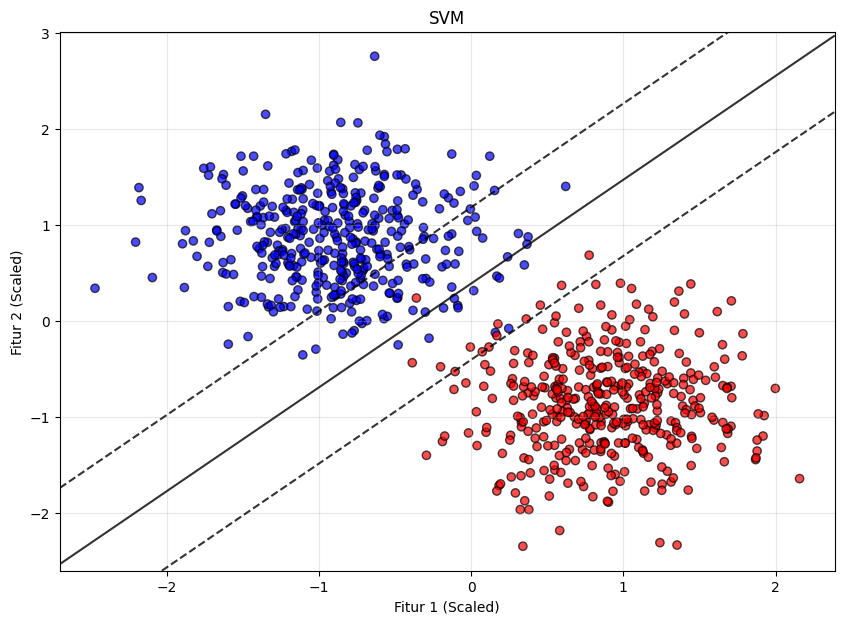

In [386]:
def visualize_svm_final(X, y, weights, bias):
    X = np.array(X)
    y = np.array(y)
    w = np.array(weights)
    
    plt.figure(figsize=(10, 7))
    
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7, edgecolors='k')
    
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    
    Z = (w[0] * XX + w[1] * YY + bias)

    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.8, linestyles=['--', '-', '--'])
    
    plt.title("SVM")
    plt.xlabel("Fitur 1 (Scaled)")
    plt.ylabel("Fitur 2 (Scaled)")
    plt.grid(True, alpha=0.3)
    plt.show()

visualize_svm_final(X_train_scaled, y_train, weights, bias)